# Benchmarking OncoTox with the real **DrEval** (`drevalpy` 1.5.1)

Runs our data and our model through the **actual published benchmarking framework**, not a
re-implementation:

> Bernett, Iversen, Picciani, **Wilhelm**, Baum, List —
> *Critical evaluation of drug response prediction models with DrEval*, **Nat. Commun. (2026)**
> · package: <https://github.com/daisybio/drevalpy> · `pip install drevalpy` (v1.5.1 used here)

**Their headline:** *"deep learning models barely outperform a naive model that predicts only the mean
drug and cell line effects"* — about half of published models fail to beat their
`NaiveMeanEffectsPredictor`. Our own finding that **ridge on 150 cell-line means ties the PCA MLP**
(notebook `ablations_and_rescue`) is the same result, independently reproduced. This notebook checks our model against
**their** baselines, **their** splits and **their** metrics.

### What is imported from `drevalpy` (nothing re-implemented)

| Their component | What we use it for |
|---|---|
| `DrugResponseDataset` | our (cell line × drug) AUC responses in their format |
| `.split_dataset(mode="LCO")` | **their** leave-cell-line-out CV splits (the personalized-medicine setting) |
| `NaivePredictor`, `NaiveDrugMeanPredictor`, `NaiveCellLineMeanPredictor`, **`NaiveMeanEffectsPredictor`** | their baselines — the bar half the field fails to clear |
| `SingleDrugRandomForest`, `SingleDrugElasticNet` | their per-drug reference models, fed **our** scGPT / PCA embeddings as the cell-line view |
| `evaluate()` | their metric implementations (Pearson / Spearman / R²) |
| their normalization recipe | subtract `NaiveMeanEffects` predictions from **y_true *and* y_pred**, then re-evaluate |

**Our model (`OncoMLP`) is trained on their splits**: single cells of the *train* lines, predictions on
the cells of the held-out lines, averaged back to one value per cell line — so it is scored on exactly
the same pairs as their models.

### One thing worth knowing before reading the numbers

In **LCO**, a held-out cell line was never seen, so `NaiveMeanEffectsPredictor` sets its cell-line effect
to **0** — the baseline reduces to *global mean + drug effect*. That has two consequences:

1. `NaiveMeanEffects` ≡ `NaiveDrugMean` in this setting (we verify it below).
2. Their **normalized** metric therefore removes the **drug** mean — which is exactly the fix for the
   Simpson's-paradox artifact they describe (pooled ρ looks great merely because drugs differ in
   potency). It does **not** remove the cell-line effect, because in LCO no honest predictor can know it.

**Target:** `--score auc` (native, un-z-scored AUC units), because DrEval works per (cell line × drug)
pair and their naive predictors estimate the drug means themselves.

> ⚠️ **The stored outputs below predate three fixes, and this notebook still cannot be re-run.**
> Every number in it was computed on the retired `auc` target, at 25 epochs, and on drugs chosen by
> the **retracted learnability gate** — a set sharing exactly one compound (`dasatinib`) with the
> current 11-drug panel. The code has since been repaired on all three counts (`66442d2`, `f993c20`,
> `af2cfa9`), so what is printed below no longer corresponds to what the code would produce. The
> outputs are kept rather than cleared so the old measurements stay legible as a record.
> **R5 re-runs this notebook**, once the sweep has written the `auc_cc` targets file and stage 4a's
> out-of-fold predictions.

In [1]:
import os
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
NB_DIR = ROOT / 'notebooks'    # outputs always live in notebooks/outputs
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch.utils.data import DataLoader

import drevalpy
from drevalpy.datasets.dataset import DrugResponseDataset, FeatureDataset
from drevalpy.evaluation import evaluate
from drevalpy.models import MODEL_FACTORY

from scripts.model.OncoMLP import OncoMLP, init_head_bias_
from scripts.training.cv import per_drug_line_mean
from scripts.training.density_weighting import line_level
from scripts.model.dataset import MultiDrugDataset
from scripts.layout import DEFAULT_CTRP_SCORE, PipelinePaths
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig, train_model

# Named per subdirectory rather than the flat outputs/ root (audit #24, 13.08.2026). This
# notebook writes into dreval/ and reads from panel/, so one constant cannot serve both --
# and a bare OUT is what makes the NEXT write land in the root. Resolved paths unchanged.
OUT_DREVAL = NB_DIR / 'outputs' / 'dreval'
OUT_PANEL = NB_DIR / 'outputs' / 'panel'
print('drevalpy', drevalpy.__version__)
print('available models:', sorted(MODEL_FACTORY.keys())[:8], '...')

drevalpy 1.5.1
available models: ['AdaBoostDecisionTree', 'DIPK', 'DrugGNN', 'ElasticNet', 'GradientBoosting', 'KNNRegressor', 'Lasso', 'MOLIR'] ...


## 1. Our data → their `DrugResponseDataset`

DrEval operates at **(cell line × drug)** resolution — which is the honest resolution of our label
anyway (it is a bulk measurement broadcast to cells). Cell-line features = the **mean embedding** of that
line's cells, for both representations.

In [2]:
# The panel, read from the artifact notebook 2 writes (Selin, 13.08.2026, review item 11).
#
# Until now this cell selected its drugs from outputs/archive/learnability/ctrp_drug_learnability_auc.csv
# -- the artifact of the kill/spare learnability gate, which this project RETRACTED. So the notebook
# that asks "how good is our model by the field's own standard" was measuring it on drugs chosen by a
# criterion we had withdrawn. That is the defect; a stale list would have been the mild version of it.
#
# This is not a refresh of a list. The retracted set (daporinad, ml210, gsk461364, oligomycin a,
# kx2-391, methotrexate, rigosertib, snx-2112, dasatinib, ml162) shares exactly ONE drug with the
# rebuilt panel -- dasatinib. Any DrEval number produced after this change is measured on a different
# set of drugs from every DrEval number produced before it, and the two are not comparable.
#
# load_panel() returns `drug_key`, the CTRPv2 spelling (e.g. 'platin'), which is what the response
# data is keyed by -- not `drug`, the FDA list's name (e.g. 'Cisplatin').
from scripts.evaluation.dreval_normalize import load_panel

PANEL = load_panel()   # was FIVE, which held ten drugs and would now hold eleven -- the name has been
                       # wrong through two panel changes, so it goes with the selection that made it.

# DEFAULT_CTRP_SCORE, not a literal: 'auc' was removed from CTRP_SCORES on 11.08.2026, so
# this raised ValueError on construction. auc_cc is also in native viability units, which is
# what DrEval needs -- it works per (cell line x drug), so a per-drug standardised target
# would make its pooled metrics meaningless (12.08.2026).
paths = PipelinePaths.build(None, 'hvg5000', DEFAULT_CTRP_SCORE)
ad = sc.read_h5ad(paths.targets_h5ad)
Y = np.asarray(ad.obsm['Y_ctrp'], float)
M = np.asarray(ad.obsm['M_ctrp'], bool)
ALL = list(ad.uns['ctrp_drugs'])
lines = ad.obs['Cell_line'].astype(str).to_numpy()
uniq = np.unique(lines)
E = {'scgpt': np.asarray(ad.obsm['X_scGPT'], float), 'pca': np.asarray(ad.obsm['X_pca'], float)}

missing = [d for d in PANEL if d not in ALL]
if missing:
    raise ValueError(
        f'Panel drugs absent from the targets file: {missing}. Present drugs are keyed as in '
        f"uns['ctrp_drugs']; re-run ctrp_to_h5ad with a lower --min-cell-lines, or check that "
        f'panel.csv carries the CTRPv2 spelling in drug_key.'
    )

pairs, cell_feats_d = [], {}
for l in uniq:
    ci = np.flatnonzero(lines == l)
    cell_feats_d[l] = {'cell_line_name': np.array([l]),
                       'scgpt': E['scgpt'][ci].mean(0),      # line = mean of its cells
                       'pca': E['pca'][ci].mean(0)}
    for d in PANEL:
        k = ALL.index(d)
        obs = ci[M[ci, k]]
        if obs.size:
            pairs.append((l, d, Y[obs, k].mean()))

response = DrugResponseDataset(
    response=np.array([p[2] for p in pairs], dtype=float),
    cell_line_ids=np.array([p[0] for p in pairs]),
    drug_ids=np.array([p[1] for p in pairs]),
    dataset_name='OncoTox_SCP542_CTRPv2',
)
cell_feats = FeatureDataset(features=cell_feats_d)
drug_feats = FeatureDataset(features={d: {'pubchem_id': np.array([d])} for d in PANEL})

print(f'{len(pairs)} (cell line x drug) pairs | {len({p[0] for p in pairs})} cell lines | {len(PANEL)} drugs')
print('drugs:', PANEL)

1918 (cell line x drug) pairs | 181 cell lines | 11 drugs
drugs: ['doxorubicin', 'platin', 'etoposide', 'paclitaxel', 'gemcitabine', 'imatinib', 'erlotinib', 'sorafenib', 'dasatinib', 'crizotinib', 'afatinib']


## 2. Their LCO splits (leave-cell-line-out)

DrEval's four settings: **LPO** (imputation), **LCO** (*personalized medicine — a new patient*), **LTO**
(drug repurposing across tissues), **LDO** (novel drug discovery). Ours is **LCO** — the same leakage
control we already used (no cell line in both train and test), now produced by *their* code.

In [3]:
response.split_dataset(n_cv_splits=5, mode='LCO', split_validation=True,
                       validation_ratio=0.1, random_state=42)
folds = response.cv_splits
tr0, te0 = folds[0]['train'], folds[0]['test']
print(f'{len(folds)} LCO folds')
print(f'fold 1: train {len(tr0.response)} pairs / {len(set(tr0.cell_line_ids))} lines | '
      f'test {len(te0.response)} pairs / {len(set(te0.cell_line_ids))} lines')
print('line overlap train/test:', set(tr0.cell_line_ids) & set(te0.cell_line_ids), '(empty = leakage-free)')

5 LCO folds
fold 1: train 1371 pairs / 129 lines | test 384 pairs / 37 lines
line overlap train/test: set() (empty = leakage-free)


## 3. Models

- **Their baselines** — incl. `NaiveMeanEffectsPredictor`, the bar half the published field fails.
- **Their `SingleDrugRandomForest` / `SingleDrugElasticNet`**, fed **our** embeddings as the cell-line
  view — i.e. their reference models on our features.
- **Our `OncoMLP`** — trained on the *single cells* of the train lines (the actual OncoTox pipeline),
  predictions averaged back to one value per held-out cell line.

In [4]:
def run_naive(name, tr, te):
    m = MODEL_FACTORY[name]()
    m.build_model({})
    m.train(output=tr, cell_line_input=cell_feats, drug_input=drug_feats)
    return m.predict(cell_line_ids=te.cell_line_ids, drug_ids=te.drug_ids,
                     cell_line_input=cell_feats, drug_input=drug_feats)


def run_their_model(name, view, tr, te):
    """Their SingleDrug* model, using OUR embedding as the cell-line view."""
    m = MODEL_FACTORY[name]()
    hp = MODEL_FACTORY[name].get_hyperparameter_set()[0].copy()
    hp['cell_line_views'] = view
    m.build_model(hp)
    preds = np.full(len(te.response), np.nan)
    for d in np.unique(te.drug_ids):                 # SingleDrug models are fit per drug
        tr_d = DrugResponseDataset(
            response=tr.response[tr.drug_ids == d], cell_line_ids=tr.cell_line_ids[tr.drug_ids == d],
            drug_ids=tr.drug_ids[tr.drug_ids == d])
        mm = MODEL_FACTORY[name]()
        mm.build_model(hp)
        mm.train(output=tr_d, cell_line_input=cell_feats, drug_input=drug_feats)
        sel = te.drug_ids == d
        preds[sel] = mm.predict(cell_line_ids=te.cell_line_ids[sel], drug_ids=te.drug_ids[sel],
                                cell_line_input=cell_feats, drug_input=drug_feats)
    return preds


def run_oncomlp(rep, tr, va, te):
    """OUR model: train on the single cells of the train lines, predict the held-out lines' cells.

    Early stopping / best-epoch selection runs on DrEval's own VALIDATION split (`sp['validation']`).
    Using the test fold here would select the model on the data it is scored on.
    """
    tr_lines, va_lines, te_lines = set(tr.cell_line_ids), set(va.cell_line_ids), set(te.cell_line_ids)
    assert not (tr_lines | va_lines) & te_lines, 'test lines leaked into train/val'
    trc = np.isin(lines, list(tr_lines))
    vac = np.isin(lines, list(va_lines))
    tec = np.isin(lines, list(te_lines))
    tr_ds = MultiDrugDataset(adata=ad, use_rep=rep, cell_mask=trc, drugs=PANEL)
    va_ds = MultiDrugDataset(adata=ad, use_rep=rep, cell_mask=vac, drugs=PANEL)
    model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=DEFAULT_HIDDEN_DIMS[rep],
                    dropout_rate=0.5, input_dropout=0.1, norm='layer',
                    output_dim=len(tr_ds.drug_names))
    # Head bias at the per-drug base rate, mirroring cv.py:375 (Selin, 13.08.2026). Audit 08 item A
    # applied this fix to "all three paths" -- there were FOUR. This one trains OncoMLP too and was
    # never enumerated, so from 12.08.2026 until today the benchmark started every drug's prediction
    # at zero while the pipeline started it at the drug's mean. On auc_cc, centred near 0.9, that
    # costs early epochs travelling to the base rate and biases the benchmark AGAINST our model --
    # the same direction as the 25-vs-50 epoch defect, in the same cell.
    # Collapsed to LINES first. per_drug_line_mean requires line-level arrays: the label is
    # constant within a line, so a cell-level mean would weigh a 1,990-cell line 35x a 56-cell
    # line for the same single measurement -- the per-cell/per-line distinction audit 08 turns on.
    _fit_lines = np.unique(tr_ds.groups)
    _y_lines, _obs_lines = line_level(tr_ds.y.numpy(), tr_ds.mask.numpy().astype(bool),
                                      tr_ds.groups, _fit_lines)
    init_head_bias_(model, per_drug_line_mean(_y_lines, _obs_lines))
    # Explicit generator (13.08.2026, Gate 4), matching cv.py:378-386. Without one, RandomSampler
    # seeds itself from the global torch RNG at iteration time, which happens to be seeded because
    # train_model calls set_seed(config.seed) first -- so the shuffle was in fact seeded, and this
    # was fragile rather than broken. It is the exact ordering dependency the pipeline already
    # decided against, and it was the last of the four training paths still carrying it.
    best, _ = train_model(model, DataLoader(tr_ds, batch_size=128, shuffle=True,
                                            generator=torch.Generator().manual_seed(42)),   # == the seed passed below
                          DataLoader(va_ds, batch_size=256, shuffle=False),
                          # epochs=50 explicitly (Selin, 12.08.2026, review item 10). This cell was the only
        # caller in the project that passed no `epochs` at all, so it fell through to
        # TrainConfig's default of 25 while 4a_percell_training and verify_variants both
        # pass 50. That is not a benchmark setting anyone chose: it meant the notebook
        # answering "how strong is this by the field's standard" trained our model for
        # half as long as the pipeline it represents, biasing the comparison against us.
        # Setting it restores the pipeline's configuration rather than changing the
        # benchmark.
        config=TrainConfig(epochs=50, seed=42, log_every=1000),
                          tag=f'dreval_{rep}', drug_names=tr_ds.drug_names)
    best = best.to('cpu').eval()
    with torch.no_grad():
        X = torch.tensor(np.asarray(ad.obsm[rep], dtype=np.float32)[tec])
        P = best(X).numpy()                          # (cells of held-out lines, K)
    cell_lines_te = lines[tec]
    # Column order comes from the dataset, not from PANEL: MultiDrugDataset resolves the requested
    # names against uns['ctrp_drugs'] and reports the order it actually used in `drug_names`.
    per_line = {(l, d): P[cell_lines_te == l, j].mean()
                for l in te_lines for j, d in enumerate(tr_ds.drug_names)}
    return np.array([per_line[(l, d)] for l, d in zip(te.cell_line_ids, te.drug_ids)])

In [5]:
BASELINES = ['NaivePredictor', 'NaiveDrugMeanPredictor', 'NaiveCellLineMeanPredictor',
             'NaiveMeanEffectsPredictor']
records = []
for fold, sp in enumerate(folds, 1):
    tr, va, te = sp['train'], sp['validation'], sp['test']
    preds = {b: run_naive(b, tr, te) for b in BASELINES}
    for view in ['pca', 'scgpt']:
        preds[f'SingleDrugRF ({view})'] = run_their_model('SingleDrugRandomForest', view, tr, te)
        preds[f'SingleDrugEN ({view})'] = run_their_model('SingleDrugElasticNet', view, tr, te)
    preds['OncoMLP (X_pca)'] = run_oncomlp('X_pca', tr, va, te)
    preds['OncoMLP (X_scGPT)'] = run_oncomlp('X_scGPT', tr, va, te)

    naive = preds['NaiveMeanEffectsPredictor']       # <- their normalization reference
    for algo, p in preds.items():
        raw = evaluate(DrugResponseDataset(response=te.response, cell_line_ids=te.cell_line_ids,
                                           drug_ids=te.drug_ids, predictions=p),
                       ['Pearson', 'Spearman', 'R^2'])
        # DrEval normalization: subtract the NaiveMeanEffects prediction from y_true AND y_pred
        norm = evaluate(DrugResponseDataset(response=te.response - naive, cell_line_ids=te.cell_line_ids,
                                            drug_ids=te.drug_ids, predictions=p - naive),
                        ['Pearson', 'Spearman', 'R^2'])
        records.append({'fold': fold, 'algorithm': algo,
                        **{f'{k}': v for k, v in raw.items()},
                        **{f'{k}: normalized': v for k, v in norm.items()}})
    print(f'fold {fold} done', flush=True)

res = pd.DataFrame(records)
OUT_DREVAL.mkdir(parents=True, exist_ok=True)
res.to_csv(OUT_DREVAL / 'dreval_lco_results.csv', index=False)

summary = res.groupby('algorithm')[['Pearson', 'Spearman', 'R^2',
                                    'Pearson: normalized', 'Spearman: normalized', 'R^2: normalized']].mean()
order = BASELINES + [c for c in summary.index if c not in BASELINES]
summary = summary.loc[order]
print('\n=== DrEval LCO, mean over 5 folds (pooled over all (line, drug) pairs) ===')
print(summary.round(3).to_string())

Loaded 32826 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.6 | min drug coverage=29820 cells | max drug coverage=32357 cells.
Loaded 3939 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.8 | min drug coverage=3388 cells | max drug coverage=3939 cells.
[dreval_X_pca] Training on device: mps
[dreval_X_pca] Multi-task mode detected (masked MSE).
[dreval_X_pca] Weight decay 0 on 74432 weight parameters; 587 bias/norm parameters exempt.


[dreval_X_pca] Epoch [01/50] | Train MSE: 0.0389 | Val MSE: 0.0212 | LR: 1.0e-03  <- best
  best : imatinib:0.004(n=3939), sorafenib:0.004(n=3388), etoposide:0.006(n=3939), platin:0.012(n=3939), crizotinib:0.015(n=3806)
  worst: gemcitabine:0.053(n=3939), paclitaxel:0.051(n=3939), afatinib:0.028(n=3939), erlotinib:0.022(n=3939), dasatinib:0.019(n=3939)


[dreval_X_pca] Early stopping at epoch 11 (no val improvement for 10 epochs).
[dreval_X_pca] Training complete. Best Val MSE: 0.0212 at epoch 1.
Loaded 32826 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.6 | min drug coverage=29820 cells | max drug coverage=32357 cells.
Loaded 3939 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.8 | min drug coverage=3388 cells | max drug coverage=3939 cells.
[dreval_X_scGPT] Training on device: mps
[dreval_X_scGPT] Multi-task mode detected (masked MSE).
[dreval_X_scGPT] Weight decay 0 on 74432 weight parameters; 587 bias/norm parameters exempt.


[dreval_X_scGPT] Epoch [01/50] | Train MSE: 0.0330 | Val MSE: 0.0204 | LR: 1.0e-03  <- best
  best : imatinib:0.004(n=3939), sorafenib:0.004(n=3388), etoposide:0.005(n=3939), platin:0.009(n=3939), crizotinib:0.015(n=3806)
  worst: paclitaxel:0.051(n=3939), gemcitabine:0.047(n=3939), afatinib:0.027(n=3939), erlotinib:0.022(n=3939), doxorubicin:0.021(n=3939)


[dreval_X_scGPT] Epoch [02/50] | Train MSE: 0.0158 | Val MSE: 0.0195 | LR: 1.0e-03  <- best
  best : imatinib:0.003(n=3939), sorafenib:0.004(n=3388), etoposide:0.006(n=3939), platin:0.010(n=3939), dasatinib:0.016(n=3939)
  worst: gemcitabine:0.048(n=3939), paclitaxel:0.045(n=3939), afatinib:0.023(n=3939), doxorubicin:0.021(n=3939), erlotinib:0.020(n=3939)


...

[dreval_X_pca] Early stopping at epoch 11 (no val improvement for 10 epochs).
[dreval_X_pca] Training complete. Best Val MSE: 0.0174 at epoch 1.
Loaded 35321 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.6 | min drug coverage=32264 cells | max drug coverage=34886 cells.
Loaded 3183 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.7 | min drug coverage=2948 cells | max drug coverage=3183 cells.
[dreval_X_scGPT] Training on device: mps
[dreval_X_scGPT] Multi-task mode detected (masked MSE).
[dreval_X_scGPT] Weight decay 0 on 74432 weight parameters; 587 bias/norm parameters exempt.


[dreval_X_scGPT] Epoch [01/50] | Train MSE: 0.0328 | Val MSE: 0.0171 | LR: 1.0e-03  <- best
  best : crizotinib:0.004(n=3183), platin:0.005(n=3183), doxorubicin:0.008(n=2986), imatinib:0.009(n=3110), etoposide:0.011(n=3056)
  worst: gemcitabine:0.041(n=3183), dasatinib:0.030(n=3183), paclitaxel:0.026(n=3056), afatinib:0.022(n=2948), erlotinib:0.018(n=2986)


[dreval_X_scGPT] Epoch [02/50] | Train MSE: 0.0163 | Val MSE: 0.0171 | LR: 1.0e-03  <- best
  best : crizotinib:0.005(n=3183), platin:0.005(n=3183), doxorubicin:0.008(n=2986), imatinib:0.010(n=3110), etoposide:0.010(n=3056)
  worst: gemcitabine:0.040(n=3183), dasatinib:0.030(n=3183), paclitaxel:0.025(n=3056), afatinib:0.023(n=2948), erlotinib:0.018(n=2986)


[dreval_X_scGPT] Early stopping at epoch 12 (no val improvement for 10 epochs).
[dreval_X_scGPT] Training complete. Best Val MSE: 0.0171 at epoch 2.
fold 5 done



=== DrEval LCO, mean over 5 folds (pooled over all (line, drug) pairs) ===
                            Pearson  Spearman    R^2  Pearson: normalized  Spearman: normalized  R^2: normalized
algorithm                                                                                                       
NaivePredictor                0.000     0.000 -0.004                0.005                 0.002           -1.119
NaiveDrugMeanPredictor        0.723     0.741  0.518                0.000                 0.000           -0.007
NaiveCellLineMeanPredictor    0.000     0.000 -0.004                0.005                 0.002           -1.119
NaiveMeanEffectsPredictor     0.723     0.741  0.518                0.000                 0.000           -0.007
OncoMLP (X_pca)               0.746     0.771  0.552                0.271                 0.271            0.064
OncoMLP (X_scGPT)             0.746     0.773  0.554                0.276                 0.272            0.068
SingleDrugEN (pca)  

## 4. Read-out

**Raw** metrics are pooled over all (cell line × drug) pairs and are inflated by drug potency
(Simpson's paradox — DrEval's central complaint). **Normalized** metrics are the honest ones: they
subtract the `NaiveMeanEffects` prediction from truth *and* prediction, leaving only the part a model
adds **beyond knowing the average drug and cell-line effect**.

The question DrEval poses to every model, and now to ours:

> **Does it beat `NaiveMeanEffectsPredictor`?** (Half of the published field does not.)

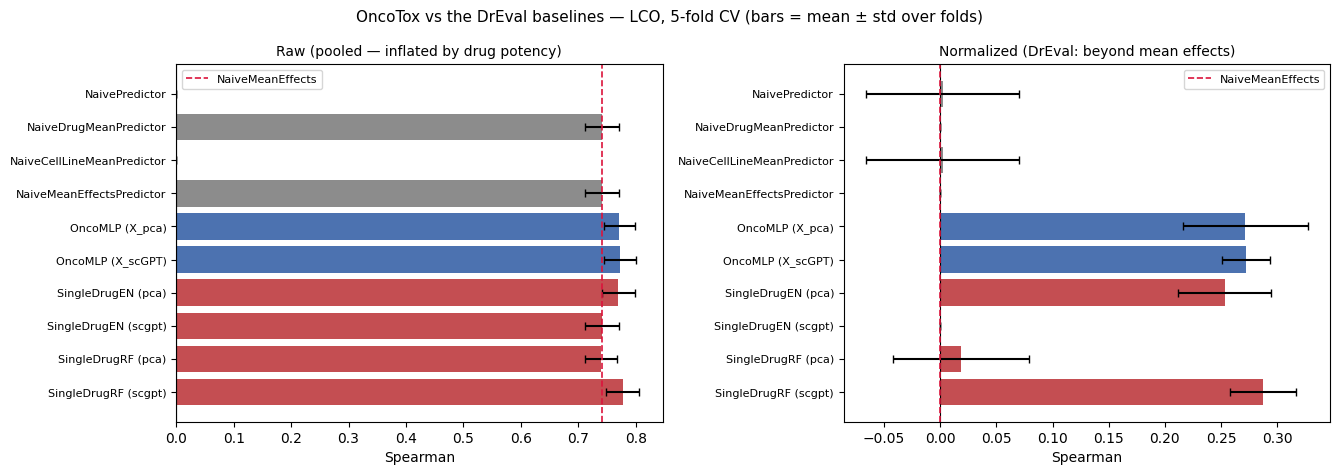

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=False)
piv = res.groupby('algorithm')[['Spearman', 'Spearman: normalized']].agg(['mean', 'std']).loc[order]
x = np.arange(len(order))
# colour by MODEL FAMILY, not by position: grey = DrEval baselines,
# red = their reference models on our features, blue = ours.
cols = ['#4C72B0' if a.startswith('OncoMLP')
        else '#C44E52' if a.startswith('SingleDrug')
        else '#8C8C8C' for a in order]

for a, col, title in [(ax[0], 'Spearman', 'Raw (pooled — inflated by drug potency)'),
                      (ax[1], 'Spearman: normalized', 'Normalized (DrEval: beyond mean effects)')]:
    m = piv[(col, 'mean')].to_numpy(); s = piv[(col, 'std')].to_numpy()
    a.barh(x, m, xerr=s, color=cols, capsize=3)
    a.axvline(0, color='k', lw=0.8)
    nme = piv.loc['NaiveMeanEffectsPredictor', (col, 'mean')]
    a.axvline(nme, color='crimson', ls='--', lw=1.2, label='NaiveMeanEffects')
    a.set_yticks(x); a.set_yticklabels(order, fontsize=8)
    a.invert_yaxis(); a.set_xlabel('Spearman'); a.set_title(title, fontsize=10); a.legend(fontsize=8)

fig.suptitle('OncoTox vs the DrEval baselines — LCO, 5-fold CV (bars = mean ± std over folds)', fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DREVAL / 'dreval_lco.png', dpi=200)
plt.show()

## Conclusion

*(Filled in from the executed cells — see `outputs/dreval/dreval_lco_results.csv`.)*

Three things this notebook establishes, using the field's own benchmark rather than our metrics:

1. **Whether OncoTox clears `NaiveMeanEffectsPredictor`** — the bar that half of the published models in
   the DrEval paper fail. Our own `ablations_and_rescue` ablation (ridge on line-means ties the PCA MLP) predicts this is
   *tight*, and the normalized column is where it is decided.
2. **PCA vs scGPT under their protocol**, on their splits, with their metrics — an external check on the
   +0.075 gap we measured ourselves.
3. **Our model vs their reference models** (`SingleDrugRandomForest` / `SingleDrugElasticNet`) fed the
   *same* embeddings — i.e. does the single-cell MLP add anything over a standard per-drug regressor on
   the line-mean embedding?

⚠️ **Caveat:** the panel is selected on FDA approval and published resistance determinants
([`2_drug_selection`](../../2_drug_selection.ipynb)), with a coverage cut applied across all cell
lines. DrEval's protocol fixes the *evaluation*; it does not make the *selection* train-only.

⚠️ **The `+0.075` PCA-vs-scGPT gap this section calls an independent replication was withdrawn**
(`1971990`), along with every other model result. Point 2 above stands as a question the re-run
answers, not as a comparison against a known number.

## 5. DrEval's normalization, applied to the pipeline's own predictions

Section 4 scored models this notebook trained itself. This section instead reads the out-of-fold
predictions [`4a_percell_training`](../../4a_percell_training.ipynb) wrote and applies DrEval's
normalization to them, so the benchmark scores the models the pipeline actually produced rather than
lookalikes of them.

**The cell-line-effect diagnostic that used to live here is retired and is not restored.** It
estimated a fragility index over all 545 drugs and applied a partial-Spearman correction — a locally
invented metric with no counterpart in DrEval's paper. Recoverable at
`git show bf93084:scripts/evaluation/dreval_normalize.py`; see
[`scripts/archive/README.md`](../../../scripts/archive/README.md).

> ⚠️ **So the question it was built to answer is still open.** Under leave-cell-line-out, DrEval's
> normalization removes the **drug** effect only — a held-out line's effect is unseen and therefore
> zero. A synthetic predictor emitting nothing but `mean + line effect + drug effect` scores
> normalized Spearman **0.98** here. A high normalized score is therefore **not** evidence of
> drug-specific biology. Whether *"signal or general fragility?"* gets answered, and how, is
> **review item 11**.

In [7]:
# Rewired to DrEval's own recipe (Selin, 12.08.2026, review item 11). This cell used to call
# line_by_drug_truth / normalized_correlations / oof_line_predictions, deleted with the
# cell-line-effect diagnostic -- a locally invented metric with no counterpart in DrEval's paper.
# That diagnostic is NOT restored; it stays retired, recoverable at
#   git show bf93084:scripts/evaluation/dreval_normalize.py
#
# The substantive change is that this no longer TRAINS. It used to refit 20 models of its own
# (K=panel and K=545, x 2 reps) purely to produce predictions to normalize. Those were a second,
# separate training path whose configuration could drift from the pipeline's -- and did: see the
# epoch fix in cell 8, where this notebook was training for 25 epochs while everything else ran 50.
# Now it reads the out-of-fold predictions 4a_percell_training already wrote, so the benchmark
# scores the models the pipeline actually produced rather than lookalikes of them.
from scripts.evaluation.dreval_normalize import load_oof, normalized_evaluation

OOF_CSV = OUT_PANEL / 'panel_oof_predictions.csv'
NORM_CSV = OUT_DREVAL / 'dreval_normalized.csv'

# load_oof refuses a frame without a `fold` column, because DrEval's naive baseline has to be fitted
# on the training folds -- fitting it on the same out-of-fold rows it is then subtracted from would
# let held-out labels define the baseline they are scored against.
#
# There is deliberately no skip-on-missing branch here (Selin, 13.08.2026). load_oof RAISES on an arm
# with no rows rather than returning an empty frame, so an `if oof.empty: continue` guard was
# unreachable and made this loop read as though it tolerated a missing arm. It does not, and should
# not: a normalized table holding two of four arms, with nothing in it saying so, is a more dangerous
# artifact than a failure. Fail where the assumption breaks rather than continue with less than the
# output claims.
if OOF_CSV.exists():
    frames = []
    for rep in ['X_pca', 'X_scGPT']:
        for alpha in [0.0, 0.5, 1.0]:      # the density-weighting levels, renamed from a bool 13.08.2026
            block = normalized_evaluation(load_oof(OOF_CSV, rep=rep, alpha=alpha))
            block.insert(0, 'alpha', alpha)
            block.insert(0, 'rep', rep)
            frames.append(block)
    norm = pd.concat(frames, ignore_index=True)
    norm.to_csv(NORM_CSV, index=False)
    print(f'{len(norm)} rows from {OOF_CSV.name} -> {NORM_CSV.name}')
else:
    raise FileNotFoundError(
        f'{OOF_CSV} does not exist yet. It is written by 4a_percell_training at R4 of the sweep. '
        f'The previously cached {NORM_CSV.name} is NOT read as a fallback: it predates the '
        f'val-split fix (ee07b00), was computed on the void 8-drug panel, and its rho_normalized '
        f'came from code that no longer exists. Falling back to it would print stale numbers that '
        f'look current.'
    )

print(norm.round(3).to_string(index=False))


72 rows from panel_oof_predictions.csv -> dreval_normalized.csv
    rep  alpha grouping        drug    n  Pearson  Spearman  Kendall    R^2   MSE  RMSE   MAE  Pearson: normalized  Spearman: normalized  Kendall: normalized  R^2: normalized
  X_pca    0.0   pooled             1635    0.739     0.768    0.571  0.544 0.017 0.131 0.094                0.291                 0.297                0.207            0.081
  X_pca    0.0 per_drug doxorubicin  152    0.283     0.307    0.199  0.077 0.017 0.129 0.104                0.302                 0.323                0.210            0.089
  X_pca    0.0 per_drug      platin  149   -0.005    -0.044   -0.030 -0.069 0.004 0.063 0.045                0.052                 0.025                0.015           -0.032
  X_pca    0.0 per_drug   etoposide  148    0.198     0.205    0.134  0.028 0.008 0.090 0.070                0.200                 0.210                0.138            0.029
  X_pca    0.0 per_drug  paclitaxel  147    0.213     0.228  